In [2]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

### DATA 1

In [1379]:
df = pd.read_excel("D:/Guvi/Projects/Vaccination/coverage-data.xlsx")

In [1380]:
df

,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52
3,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,COUNTRIES,ABW,Aruba,2023.0,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.0,1008.0,82.69
...,...,...,...,...,...,...,...,...,...,...,...
399854,WHO_REGIONS,WPR,Western Pacific Region,1980.0,MCV1,"Measles-containing vaccine, 1st dose",WUENIC,WHO/UNICEF Estimates of National Immunization ...,27939588.0,1209026.0,4.00
399855,WHO_REGIONS,WPR,Western Pacific Region,1980.0,PAB,Protection at birth (PAB) against neonatal tet...,PAB,PAB Estimates,4494513.0,276306.0,6.00
399856,WHO_REGIONS,WPR,Western Pacific Region,1980.0,POL3,"Polio, 3rd dose",WUENIC,WHO/UNICEF Estimates of National Immunization ...,27939588.0,1296611.0,5.00
399857,WHO_REGIONS,WPR,Western Pacific Region,1980.0,RCV1,"Rubella-containing vaccine, 1st dose",WUENIC,WHO/UNICEF Estimates of National Immunization ...,27939588.0,40245.0,0.00


In [ ]:
#this is for power BI usage 
df["ANTIGEN"].unique()

array(['BCG', 'DIPHCV4', 'DIPHCV5', 'DIPHCV6', 'DTPCV1', 'DTPCV3',
       'FLU_ALL', 'FLU_CHILD1', 'FLU_CHILD2', 'FLU_CHRONIC_ADULT',
       'FLU_CHRONIC_PED', 'FLU_ELDERLY', 'FLU_HCW', 'FLU_OTHER', 'FLU_PW',
       'FLU_RESIDENT', 'HEPB_BD', 'HEPB_BDALL', 'HEPB3', 'HIB3',
       'HPV_FEM', 'HPV_MALE', 'IPV1', 'IPV1_FRAC', 'IPV2', 'IPV2_FRAC',
       'MCV1', 'MCV2', 'MENACYW_C', 'MENB_C', 'PAB', 'PCV1', 'PCV2',
       'PCV3', 'PERCV_PW', 'PERCV4', 'POL3', 'RCV1', 'ROTA1', 'ROTAC',
       'TT2PLUS', 'TTCV4', 'TTCV5', 'TTCV6', 'TYPHOID_CONJ', 'VAD1',
       'YFV', 'FLU_CHRONIC_ALL', 'FLU_HAJ', 'MEN_ACYW_CONJ', 'MEN_B',
       'MEN_A_CONJ', 'JAPENC', 'TYPHOID', '15HPV1_F', '15HPV1_M',
       '15HPVC_F', '15HPVC_M', 'MALARIA1', 'MALARIA3', 'MALARIA4',
       'PRHPV1_F', 'PRHPV1_M', 'PRHPVC_F', 'PRHPVC_M', 'JAPENC_1',
       'JAPENC_C', 'MENA_C', 'MCV2X2'], dtype=object)

In [1402]:
df.isnull().sum()

GROUP                            0
CODE                             0
NAME                             0
YEAR                             0
ANTIGEN                          0
ANTIGEN_DESCRIPTION              0
COVERAGE_CATEGORY                0
COVERAGE_CATEGORY_DESCRIPTION    0
TARGET_NUMBER                    0
DOSES                            0
COVERAGE                         0
dtype: int64

In [1389]:
df[df["COVERAGE"].isna()]

,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
12,COUNTRIES,ABW,Aruba,2023.0,FLU_ALL,Influenza all persons above >6 months (univers...,ADMIN,Administrative coverage,NaN,NaN,NaN
13,COUNTRIES,ABW,Aruba,2023.0,FLU_CHILD1,Influenza child age group 1,ADMIN,Administrative coverage,NaN,NaN,NaN
14,COUNTRIES,ABW,Aruba,2023.0,FLU_CHILD2,Influenza child age group 2,ADMIN,Administrative coverage,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
398607,WHO_REGIONS,EUR,European Region,1984.0,PAB,Protection at birth (PAB) against neonatal tet...,PAB,PAB Estimates,1586916.0,NaN,NaN
398614,WHO_REGIONS,EUR,European Region,1983.0,PAB,Protection at birth (PAB) against neonatal tet...,PAB,PAB Estimates,1589890.0,NaN,NaN
398621,WHO_REGIONS,EUR,European Region,1982.0,PAB,Protection at birth (PAB) against neonatal tet...,PAB,PAB Estimates,1592099.0,NaN,NaN
398628,WHO_REGIONS,EUR,European Region,1981.0,PAB,Protection at birth (PAB) against neonatal tet...,PAB,PAB Estimates,1607179.0,NaN,NaN


#CLEANING 

In [1383]:
#CLEARNIGN THE MANUAL NA IN THE NAME COULMN 

df["NAME"]=df["NAME"].fillna("NONE")

In [1386]:
#DROPPING OFF THE EXTRA ROW AT THE END
df.dropna(subset=["CODE"], inplace=True)

In [1390]:
#cleaning the rest of the coverage and target 

#1 filling the Doses & Target num where coverage is not null 

mask = df["COVERAGE"].notna()
df.loc[mask, "DOSES"] = df.loc[mask, "DOSES"].ffill()
df.loc[mask, "TARGET_NUMBER"] = df.loc[mask, "TARGET_NUMBER"].ffill()

In [1398]:
#2 filling coverage Null where dose and target numbers are there
mask = (df["COVERAGE"].isna() & df["DOSES"].notna() & df["TARGET_NUMBER"].notna())

df.loc[mask, "COVERAGE"] = (df.loc[mask, "DOSES"]/df.loc[mask, "TARGET_NUMBER"])*100

In [1422]:
#additional cleaning 
#if dose has an value and traget is 0 it might end in infinity makng it impossible to load in sql 

import numpy as np

#relaing the inf with Nan 
df.replace([np.inf, -np.inf], np.nan, inplace=True)

#filling the nan with 0 
df.fillna(0, inplace=True)

In [1423]:
#CHECKING 
df[(df["CODE"]=="MSR")&(df["DOSES"]==60) &(df["TARGET_NUMBER"]==60)]

,GROUP_name,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
235466,COUNTRIES,MSR,Montserrat,2000,HEPB_BD,"HepB, birth dose (given within 24 hours of birth)",ADMIN,Administrative coverage,60,60,100.0


In [1401]:
#3 Filling the rest of the values with 0 as in all the 3 columns either 2 columns has no values so cannot be filled with data 
df.loc[df["TARGET_NUMBER"].isna(), "TARGET_NUMBER"] = 0
df.loc[df["DOSES"].isna(), "DOSES"] = 0
df.loc[df["COVERAGE"].isna(), "COVERAGE"] = 0

In [1424]:
#checking 
df[(df["CODE"]=="ABW")&(df["COVERAGE_CATEGORY"]=="ADMIN")]

,GROUP_name,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023,BCG,BCG,ADMIN,Administrative coverage,0,0,0.00
2,COUNTRIES,ABW,Aruba,2023,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044,945,90.52
4,COUNTRIES,ABW,Aruba,2023,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219,1008,82.69
6,COUNTRIES,ABW,Aruba,2023,DIPHCV6,"Diphtheria-containing vaccine, 6th dose (3rd b...",ADMIN,Administrative coverage,1468,1219,83.04
8,COUNTRIES,ABW,Aruba,2023,DTPCV1,"DTP-containing vaccine, 1st dose",ADMIN,Administrative coverage,945,926,97.99
...,...,...,...,...,...,...,...,...,...,...,...
458,COUNTRIES,ABW,Aruba,2017,ROTA1,"Rotavirus, 1st dose",ADMIN,Administrative coverage,0,0,0.00
460,COUNTRIES,ABW,Aruba,2017,ROTAC,"Rotavirus, last dose",ADMIN,Administrative coverage,0,0,0.00
462,COUNTRIES,ABW,Aruba,2017,TT2PLUS,"Tetanus toxoid-containing vaccine, 2nd and sub...",ADMIN,Administrative coverage,0,0,0.00
464,COUNTRIES,ABW,Aruba,2017,VAD1,"Vitamin A, 1st dose",ADMIN,Administrative coverage,0,0,0.00


In [ ]:
df=df.rename(columns={'GROUP':'GROUP_name'})
df['YEAR'] = df['YEAR'].astype(int)
df['TARGET_NUMBER'] = df['TARGET_NUMBER'].astype(int)
df['DOSES'] = df['DOSES'].astype(int)
df

,GROUP_name,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023,BCG,BCG,ADMIN,Administrative coverage,0,0,0.00
1,COUNTRIES,ABW,Aruba,2023,BCG,BCG,OFFICIAL,Official coverage,0,0,0.00
2,COUNTRIES,ABW,Aruba,2023,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044,945,90.52
3,COUNTRIES,ABW,Aruba,2023,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,1044,945,90.52
4,COUNTRIES,ABW,Aruba,2023,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219,1008,82.69
...,...,...,...,...,...,...,...,...,...,...,...
399853,WHO_REGIONS,WPR,Western Pacific Region,1980,DTPCV3,"DTP-containing vaccine, 3rd dose",WUENIC,WHO/UNICEF Estimates of National Immunization ...,27939588,2273390,8.00
399854,WHO_REGIONS,WPR,Western Pacific Region,1980,MCV1,"Measles-containing vaccine, 1st dose",WUENIC,WHO/UNICEF Estimates of National Immunization ...,27939588,1209026,4.00
399855,WHO_REGIONS,WPR,Western Pacific Region,1980,PAB,Protection at birth (PAB) against neonatal tet...,PAB,PAB Estimates,4494513,276306,6.00
399856,WHO_REGIONS,WPR,Western Pacific Region,1980,POL3,"Polio, 3rd dose",WUENIC,WHO/UNICEF Estimates of National Immunization ...,27939588,1296611,5.00


#### SQL

In [14]:
import mysql.connector 

In [15]:
from getpass import getpass   
from mysql.connector import connect, Error

In [ ]:
# connection=mysql.connector.connect(
#         host="localhost",
#         user=input("Enter username"),   
#         password = getpass("enter the password: "),
#      )

In [ ]:
# connect = connection.cursor()

In [ ]:
create_query="CREATE DATABASE IF NOT EXISTS VACCINATION"
connect.execute(create_query)

In [18]:
use = "USE VACCINATION"
connect.execute(use)

In [1412]:
df.columns

Index(['GROUP_name', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION',
       'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER',
       'DOSES', 'COVERAGE'],
      dtype='object')

In [1425]:
drop = "DROP TABLE COVERAGE"
connect.execute(drop)

In [1426]:
table = """CREATE TABLE IF NOT EXISTS COVERAGE (
    GROUP_name VARCHAR(100),
    CODE VARCHAR(100),
    NAME VARCHAR(100),
    YEAR INT,
    ANTIGEN VARCHAR(100),
    ANTIGEN_DESCRIPTION VARCHAR(100), 
    COVERAGE_CATEGORY VARCHAR(100),
    COVERAGE_CATEGORY_DESCRIPTION VARCHAR(100),
    TARGET_NUMBER BIGINT,
    DOSES BIGINT,
    COVERAGE FLOAT
)"""

In [1427]:
connect.execute(table)
connection.commit()

In [1428]:
insert="""
INSERT INTO COVERAGE (GROUP_name, CODE, NAME, YEAR, ANTIGEN, ANTIGEN_DESCRIPTION, COVERAGE_CATEGORY, COVERAGE_CATEGORY_DESCRIPTION, TARGET_NUMBER, DOSES, COVERAGE)
VALUES(%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
"""

In [1429]:
for index, row in df.iterrows():
    connect.execute(insert, (
        row['GROUP_name'],
        row['CODE'],
        row['NAME'],
        row['YEAR'],
        row['ANTIGEN'],
        row['ANTIGEN_DESCRIPTION'],
        row['COVERAGE_CATEGORY'],
        row['COVERAGE_CATEGORY_DESCRIPTION'],
        row['TARGET_NUMBER'],
        row['DOSES'],
        row['COVERAGE']
    ))

In [1430]:
connection.commit()

#### EDA

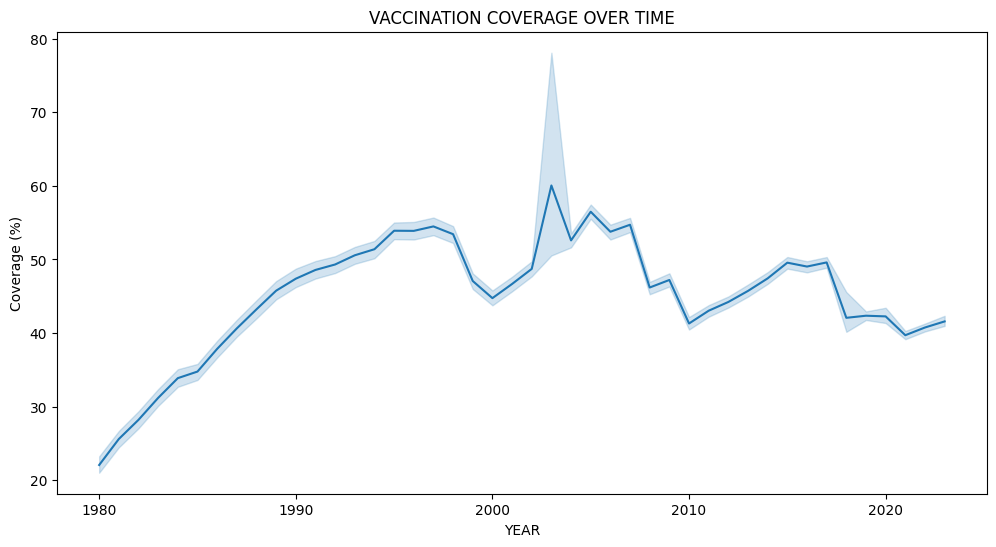

In [1450]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="YEAR", y="COVERAGE")
plt.title("VACCINATION COVERAGE OVER TIME")
plt.ylabel("Coverage (%)")
plt.show()



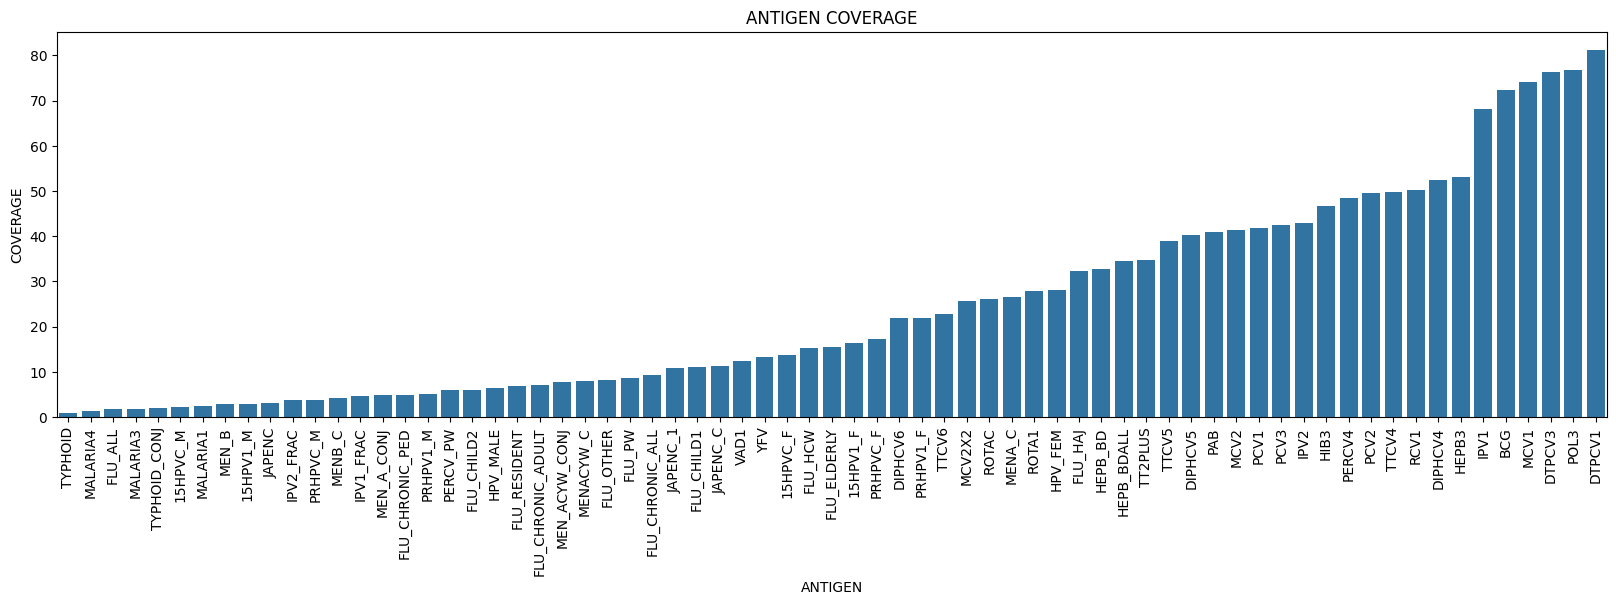

In [1577]:
#antigen coverage 
plt.figure(figsize=(20,5))
data = df.groupby('ANTIGEN')['COVERAGE'].mean().sort_values().reset_index()
sns.barplot(data=data, x='ANTIGEN',y='COVERAGE')
plt.title("ANTIGEN COVERAGE")
plt.xticks(rotation=90)
plt.show()

### DATA 2

In [344]:
df3 = pd.read_excel("D:/Guvi/Projects/Vaccination/incidence-rate-data.xlsx")

In [407]:
df3

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE,INCIDENCE_RATE_fill
0,COUNTRIES,ABW,Aruba,2023,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0,NaN
1,COUNTRIES,ABW,Aruba,2023,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0,NaN
2,COUNTRIES,ABW,Aruba,2023,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3,NaN
3,COUNTRIES,ABW,Aruba,2023,MEASLES,Measles,"per 1,000,000 total population",0.0,NaN
4,COUNTRIES,ABW,Aruba,2023,MUMPS,Mumps,"per 1,000,000 total population",0.0,NaN
...,...,...,...,...,...,...,...,...,...
84940,COUNTRIES,ZWE,Zimbabwe,1980,NTETANUS,Neonatal tetanus,"per 1,000 live births",0.4,NaN
84941,COUNTRIES,ZWE,Zimbabwe,1980,PERTUSSIS,Pertussis,"per 1,000,000 total population",893.3,NaN
84942,COUNTRIES,ZWE,Zimbabwe,1980,POLIO,Poliomyelitis,"per 1,000,000 <15 population",NaN,NaN
84943,COUNTRIES,ZWE,Zimbabwe,1980,TTETANUS,Total tetanus,"per 1,000,000 total population",19.7,NaN


In [1315]:
df3.isnull().sum()

GROUP                  0
CODE                   0
NAME                   0
YEAR                   0
DISEASE                0
DISEASE_DESCRIPTION    0
DENOMINATOR            0
INCIDENCE_RATE         0
dtype: int64

In [347]:
#DROPPING THAT LAST EMPTY ROW IN ALL THE COLUMNS 
df3.dropna(subset=["CODE", "NAME", "YEAR", "DISEASE", "DISEASE_DESCRIPTION","DENOMINATOR"], inplace=True)

In [349]:
#standardizing the year for better alignment SQL and mergers 
df3["YEAR"] = df3["YEAR"].astype(int)

In [350]:
#Filling the NA (compare the reported casese)
df3.loc[(df3["CODE"] == "ABW") & (df3["INCIDENCE_RATE"].isna()), "INCIDENCE_RATE" ] = 0

In [86]:
#CLASS FOR FILTERED ACCESSING NULL VALUES FOR FILLING 

class DataFrameFilter:
    def __init__(self, df3):
        self.df3=df3
    
    #Filter the empty data set to see in case:
    def filter_rows(self, filter_condition:dict):
        condition = pd.Series([True]*len(self.df3))
        for col, value in filter_condition.items():
            if isinstance(value, list):
                condition &= self.df3[col].isin(value)
            else:
                condition &= (self.df3[col] == value)
        return self.df3[condition]
    
    #Fill the null values with specific values:
    def fill_null(self, filter_condition:dict, column_to_fill:str, fill_value):
        mask = pd.Series([True]*len(self.df3))
        for col, value in filter_condition.items():
            if isinstance(value, list):
                mask &= self.df3[col].isin(value)
            else:
                mask &= (self.df3[col]==value)
        self.df3.loc[mask & self.df3[column_to_fill].isna(), column_to_fill] = fill_value

    #Filling for Bfill/Ffill 
    def f_bfill_null(self, filter_condition:dict, column_to_fill:str, method="bfill"):
        mask = pd.Series([True]*len(self.df3))
        for col, value in filter_condition.items():
            if isinstance (value, list):
                mask &= self.df3[col].isin(value)
            else:
                mask &= (self.df3[col]==value)
        if method == "bfill":
            self.df3.loc[mask, column_to_fill] = self.df3.loc[mask, column_to_fill].bfill()
        elif method == "ffill":
            self.df3.loc[mask, column_to_fill] = self.df3.loc[mask, column_to_fill].ffill()
        else:
            raise ValueError("Use method only ffill or bfill")




In [1314]:
df3.loc[(df3["DISEASE"]=="POLIO")&(df3["INCIDENCE_RATE"].isna()), "CODE"].unique()

array([], dtype=object)

In [ ]:
#filtered conditions for multiple usages
 
filtered_conditions = {
    "CODE" : 'ZWE',
    "DISEASE" : "RUBELLA",
    # "YEAR" : [1981, 1982,1983,1984]
}

In [1262]:
#filling using class:(edited for mutiple entries using same code) FOR BFILL AND FFILL
df_fix=DataFrameFilter(df3)

df_fix.f_bfill_null(
    filter_condition=filtered_conditions,
    column_to_fill= "INCIDENCE_RATE",
    method= "bfill"
)

In [1264]:
#FILL USING CLASS FOR SPECIFIC VALUE (MUL USAGE)
df_fix = DataFrameFilter(df3)

df_fix.fill_null(
    filter_condition=filtered_conditions,
    column_to_fill="INCIDENCE_RATE",
    fill_value=0
)

In [ ]:
#for larger column filling in the incidence rate only loading the seperately prepared data
i= pd.read_excel("D:/Guvi/Projects/Vaccination/ADDITIONAL NEEDS/cal.xlsx")
# i_r = i["INCIDENCE RATE"]

In [ ]:
#FOR FILLING MULTIPLE COULUMNS BY CREATING A DATA FRAME FOR MERGING 
# import numpy as np
# years = list(range(2023, 1979, -1))
# codes = ["BGD", "BGR"]
# CODE=[]
# YEARS=[]

# CODE=np.repeat(codes, len(years))
# YEARS = years*len(codes)

# fill_data = pd.DataFrame({
#     'CODE': CODE,
#     'YEAR': YEARS,
#     "DISEASE" : ["POLIO"]*len(CODE),
#     'INCIDENCE_RATE': i_r
# })

In [1298]:
#using Merger fill for diff value fills

#merging 
df3 = df3.merge(i, on=["CODE", "YEAR", "DISEASE"], how="left", suffixes=('', '_fill'))


In [1305]:
df3.isna().sum()

GROUP                      0
CODE                       0
NAME                       0
YEAR                       0
DISEASE                    0
DISEASE_DESCRIPTION        0
DENOMINATOR                0
INCIDENCE_RATE             0
CASE                   77485
POPULATION             83752
%<15                   83737
CASE PER 1m            83698
INCIDENCE RATE         76694
dtype: int64

In [1302]:
# Filling
df3.loc[
    # (df3["CODE"].isin(["BGD", "BGR"])) &
    (df3["DISEASE"] == "POLIO") &
    (df3["INCIDENCE_RATE"].isna()),"INCIDENCE_RATE"] = df3["INCIDENCE RATE"]

In [ ]:
#dropping the extra after filling 
df3.drop(columns=["INCIDENCE RATE", "CASE","%<15","CASE PER 1m", "POPULATION "], inplace=True)
df3

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3
3,COUNTRIES,ABW,Aruba,2023,MEASLES,Measles,"per 1,000,000 total population",0.0
4,COUNTRIES,ABW,Aruba,2023,MUMPS,Mumps,"per 1,000,000 total population",0.0
...,...,...,...,...,...,...,...,...
84940,COUNTRIES,ZWE,Zimbabwe,1980,NTETANUS,Neonatal tetanus,"per 1,000 live births",0.4
84941,COUNTRIES,ZWE,Zimbabwe,1980,PERTUSSIS,Pertussis,"per 1,000,000 total population",893.3
84942,COUNTRIES,ZWE,Zimbabwe,1980,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.0
84943,COUNTRIES,ZWE,Zimbabwe,1980,TTETANUS,Total tetanus,"per 1,000,000 total population",19.7


In [ ]:
# print(df3.loc[df3["DISEASE"]=="PERTUSSIS", "INCIDENCE_RATE"].isna().sum())
# print(df3.loc[df3["DISEASE"]=="POLIO","INCIDENCE_RATE"].isna().sum())
# print(df3.loc[df3["DISEASE"]=="RUBELLA","INCIDENCE_RATE"].isna().sum())
# print(df3.loc[df3["DISEASE"]=="TTETANUS","INCIDENCE_RATE"].isna().sum())
# print(df3.loc[df3["DISEASE"]=="TYPHOID","INCIDENCE_RATE"].isna().sum())
# print(df3.loc[df3["DISEASE"]=="YFEVER","INCIDENCE_RATE"].isna().sum())


0


In [ ]:
#CORRECTION OF DATA IN A PARTICULAR CELL INCIDENT RATE NULL IS FILLED WITH INCORRECT DATA FOR 1980 POLIO   -  LEARNING CODE 
# condition = (
    # (df3["GROUP"] == "COUNTRIES") &
    # (df3["CODE"] == "AFG") &
    # (df3["YEAR"] == 1980.0) &
    # (df3["DISEASE"] == "TYPHOID")
# )
# df3.loc[condition, "INCIDENCE_RATE"] = df["INCIDENCE_RATE"]

In [1433]:
df3.loc[(df3["CODE"]=="IND")&(df3["DISEASE"]=="POLIO")]

,GROUP_name,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
35167,COUNTRIES,IND,India,2023,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000
35180,COUNTRIES,IND,India,2022,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000
35193,COUNTRIES,IND,India,2021,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000
35206,COUNTRIES,IND,India,2020,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000
35218,COUNTRIES,IND,India,2019,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000
35230,COUNTRIES,IND,India,2018,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000
35242,COUNTRIES,IND,India,2017,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000
35253,COUNTRIES,IND,India,2016,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000
35264,COUNTRIES,IND,India,2015,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000
35275,COUNTRIES,IND,India,2014,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.000000


In [ ]:
df3.dropna(inplace=True)

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.000000
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.000000
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.300000
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,"per 1,000,000 total population",109.448781
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,"per 1,000,000 total population",0.000000
...,...,...,...,...,...,...,...,...
84940,COUNTRIES,ZWE,Zimbabwe,1980.0,NTETANUS,Neonatal tetanus,"per 1,000 live births",0.400000
84941,COUNTRIES,ZWE,Zimbabwe,1980.0,PERTUSSIS,Pertussis,"per 1,000,000 total population",893.300000
84942,COUNTRIES,ZWE,Zimbabwe,1980.0,POLIO,Poliomyelitis,"per 1,000,000 <15 population",109.448781
84943,COUNTRIES,ZWE,Zimbabwe,1980.0,TTETANUS,Total tetanus,"per 1,000,000 total population",19.700000


In [1316]:
#RENAMING FOR SQL DATABASE 
df3 = df3.rename(columns={'GROUP' : 'GROUP_name'})
df3['YEAR'] = df3['YEAR'].astype(int)
df3

,GROUP_name,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3
3,COUNTRIES,ABW,Aruba,2023,MEASLES,Measles,"per 1,000,000 total population",0.0
4,COUNTRIES,ABW,Aruba,2023,MUMPS,Mumps,"per 1,000,000 total population",0.0
...,...,...,...,...,...,...,...,...
84940,COUNTRIES,ZWE,Zimbabwe,1980,NTETANUS,Neonatal tetanus,"per 1,000 live births",0.4
84941,COUNTRIES,ZWE,Zimbabwe,1980,PERTUSSIS,Pertussis,"per 1,000,000 total population",893.3
84942,COUNTRIES,ZWE,Zimbabwe,1980,POLIO,Poliomyelitis,"per 1,000,000 <15 population",0.0
84943,COUNTRIES,ZWE,Zimbabwe,1980,TTETANUS,Total tetanus,"per 1,000,000 total population",19.7


In [1578]:
print(df3['INCIDENCE_RATE'].nunique())

# Check the distribution
print(df3['INCIDENCE_RATE'].describe())

# Check the number of missing values
print(df3['INCIDENCE_RATE'].isna().sum())

6152
count    84945.000000
mean        87.849795
std        897.588367
min          0.000000
25%          0.000000
50%          0.000000
75%          2.100000
max      69101.300000
Name: INCIDENCE_RATE, dtype: float64
0


#### sql for data3

In [ ]:
#SQL CONNECTIONS 

# connection=mysql.connector.connect(
#         host="localhost",
#         user=input("Enter username"),   
#         password = getpass("enter the password: "),
#      )

In [1344]:
connect=connection.cursor()
USE = "USE VACCINATION"
connect.execute(USE)

In [1347]:
table = """CREATE TABLE IF NOT EXISTS INCIDENT (
    GROUP_name VARCHAR(100),
    CODE VARCHAR(100),
    NAME VARCHAR(100),
    YEAR INT,
    DISEASE VARCHAR(100),
    DISEASE_DESCRIPTION VARCHAR(100), 
    DENOMINATOR VARCHAR(100),
    INCIDENCE_RATE DOUBLE
    
)"""

In [1348]:
connect.execute(table)
connection.commit()

In [147]:
df3.columns

Index(['GROUP_name', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION',
       'DENOMINATOR', 'INCIDENCE_RATE'],
      dtype='object')

In [1349]:
insert="""
INSERT INTO INCIDENT (GROUP_name, CODE, NAME, YEAR, DISEASE, DISEASE_DESCRIPTION, DENOMINATOR,  INCIDENCE_RATE )
VALUES(%s,%s,%s,%s,%s,%s,%s,%s)
"""

In [1350]:
for index, row in df3.iterrows():
    connect.execute(insert, (
        row['GROUP_name'],
        row['CODE'],
        row['NAME'],
        row['YEAR'],
        row['DISEASE'],
        row['DISEASE_DESCRIPTION'],
        row['DENOMINATOR'],
        row['INCIDENCE_RATE']
    ))

In [1351]:
connection.commit()

#### EDA

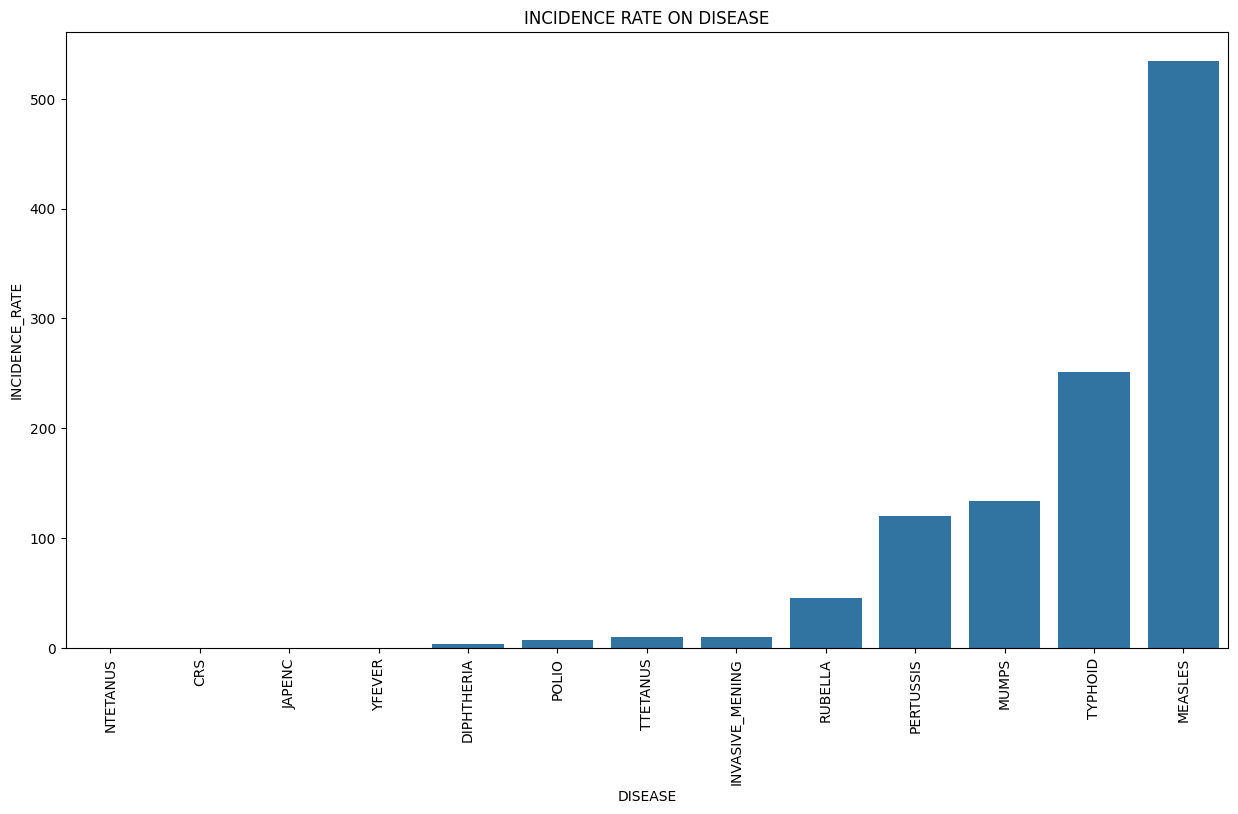

In [1575]:
#DISEASE wise incidence rate 
plt.figure(figsize=(15,8))
data = df3.groupby('DISEASE')['INCIDENCE_RATE'].mean().sort_values().reset_index()
sns.barplot(data=data, x='DISEASE',y='INCIDENCE_RATE')
plt.title("INCIDENCE RATE ON DISEASE")
plt.xticks(rotation=90)
plt.show()

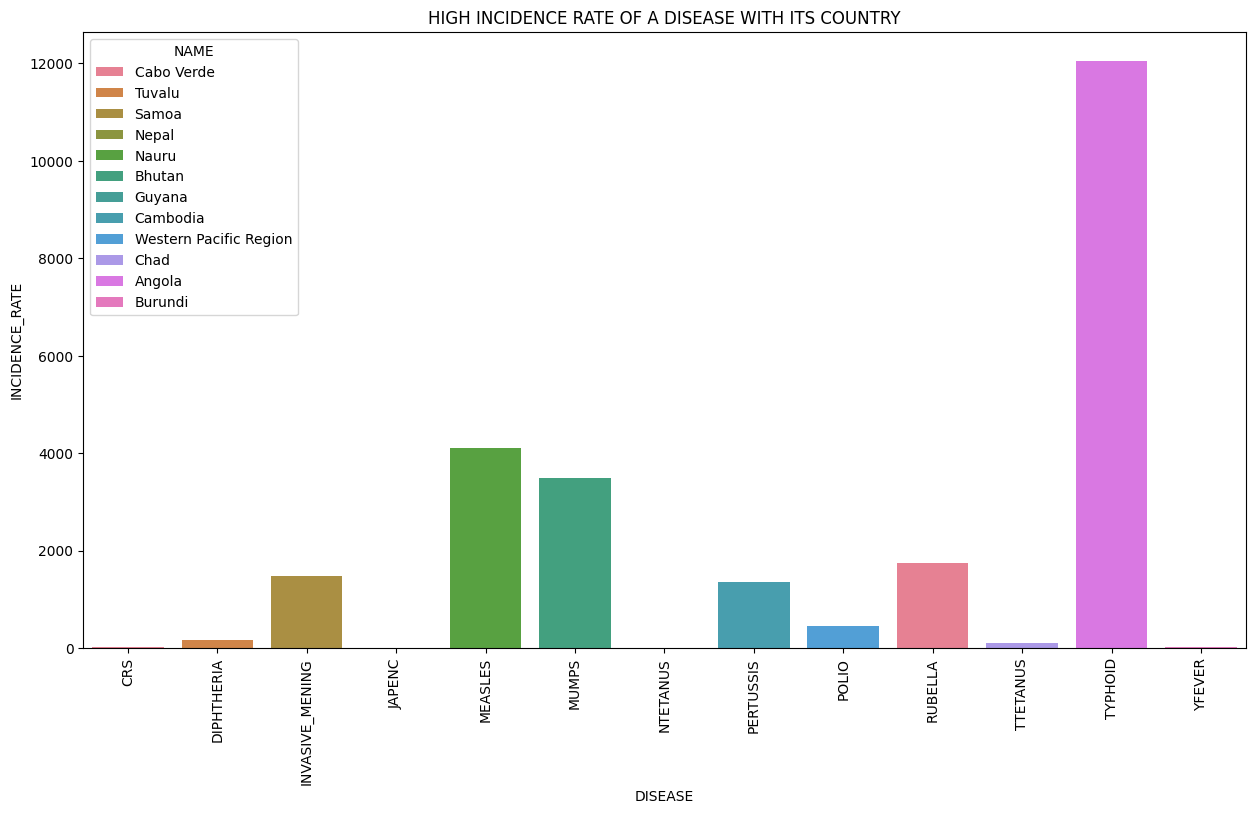

In [1574]:
#HIGH DISEASE INCIDENCE RATE
plt.figure(figsize=(15,8))
data = df3.groupby(['DISEASE','NAME'])['INCIDENCE_RATE'].mean().sort_values().reset_index()
sort = data.loc[data.groupby('DISEASE')['INCIDENCE_RATE'].idxmax()]
sns.barplot(data=sort, x='DISEASE',y='INCIDENCE_RATE', hue="NAME")
plt.title("HIGH INCIDENCE RATE OF A DISEASE WITH ITS COUNTRY")
plt.xticks(rotation=90)
plt.show()

### DATA3

In [1359]:
df4=pd.read_excel("D:/Guvi/Projects/Vaccination/reported-cases-data.xlsx")
df4

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,NaN
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,0.0
...,...,...,...,...,...,...,...
84865,COUNTRIES,ZWE,Zimbabwe,1980.0,PERTUSSIS,Pertussis,6290.0
84866,COUNTRIES,ZWE,Zimbabwe,1980.0,POLIO,Poliomyelitis,32.0
84867,COUNTRIES,ZWE,Zimbabwe,1980.0,TTETANUS,Total tetanus,139.0
84868,COUNTRIES,ZWE,Zimbabwe,1980.0,YFEVER,Yellow fever,NaN


In [1365]:
df4.isnull().sum()

GROUP                  0
CODE                   0
NAME                   0
YEAR                   0
DISEASE                0
DISEASE_DESCRIPTION    0
CASES                  0
dtype: int64

In [1361]:
#FILLING THE REPORTED CASES (0 IS USED AS MOST OF THE MISSING DATA FROM YEAR RANGE 1980 TO 1990'S WHRE WHO DATA IS INCOMPLETE AND CANNOT BE FOUND)
df4.loc[df4["CASES"].isna(), "CASES"] = 0

In [1363]:
#droping 1 extra row at the table end 
df4.dropna(inplace=True)

In [1364]:
df4

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,0.0
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,0.0
...,...,...,...,...,...,...,...
84864,COUNTRIES,ZWE,Zimbabwe,1980.0,NTETANUS,Neonatal tetanus,134.0
84865,COUNTRIES,ZWE,Zimbabwe,1980.0,PERTUSSIS,Pertussis,6290.0
84866,COUNTRIES,ZWE,Zimbabwe,1980.0,POLIO,Poliomyelitis,32.0
84867,COUNTRIES,ZWE,Zimbabwe,1980.0,TTETANUS,Total tetanus,139.0


In [1366]:
df4 = df4.rename(columns={'GROUP':'GROUP_name'})
df4['YEAR'] = df4['YEAR'].astype(int)

In [1367]:
df4

,GROUP_name,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023,INVASIVE_MENING,Invasive meningococcal disease,1.0
3,COUNTRIES,ABW,Aruba,2023,MEASLES,Measles,0.0
4,COUNTRIES,ABW,Aruba,2023,MUMPS,Mumps,0.0
...,...,...,...,...,...,...,...
84864,COUNTRIES,ZWE,Zimbabwe,1980,NTETANUS,Neonatal tetanus,134.0
84865,COUNTRIES,ZWE,Zimbabwe,1980,PERTUSSIS,Pertussis,6290.0
84866,COUNTRIES,ZWE,Zimbabwe,1980,POLIO,Poliomyelitis,32.0
84867,COUNTRIES,ZWE,Zimbabwe,1980,TTETANUS,Total tetanus,139.0


#### SQL

In [ ]:
# SQL CONNECTION
# connection=mysql.connector.connect(
#         host="localhost",
#         user=input("Enter username"),   
#         password = getpass("enter the password: "),
#      )

In [1368]:
table = """CREATE TABLE IF NOT EXISTS REPORTED_CASE (
    GROUP_name VARCHAR(100),
    CODE VARCHAR(100),
    NAME VARCHAR(100),
    YEAR INT,
    DISEASE VARCHAR(100),
    DISEASE_DESCRIPTION VARCHAR(100),
    CASES FLOAT
    )
    """

In [1369]:
connect.execute(table)
connection.commit()

In [ ]:
# DROP = "DROP TABLE REPORTED_CASE"
# connect.execute(DROP)

In [1370]:
insert="""
INSERT INTO REPORTED_CASE (GROUP_name, CODE, NAME, YEAR, DISEASE, DISEASE_DESCRIPTION, CASES )
VALUES(%s,%s,%s,%s,%s,%s,%s)
"""

In [1371]:
for index, row in df4.iterrows():
    connect.execute(insert, (
        row['GROUP_name'],
        row['CODE'],
        row['NAME'],
        row['YEAR'],
        row['DISEASE'],
        row['DISEASE_DESCRIPTION'],
        row['CASES'],
    ))

In [1372]:
connection.commit()

#### EDA

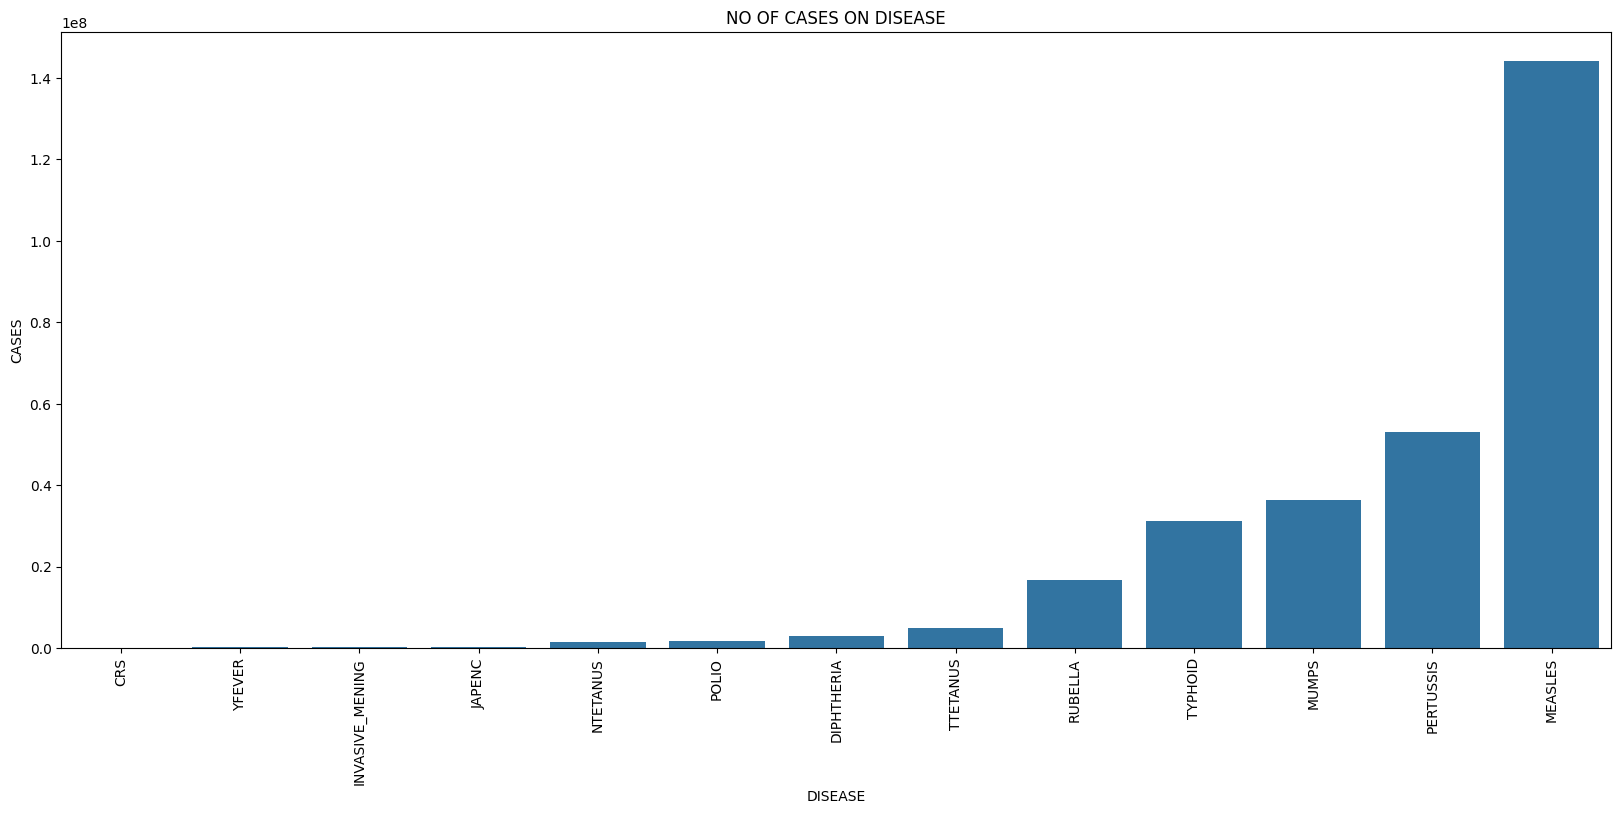

In [1479]:
#CASES ON DISEASES 
plt.figure(figsize=(20,8))
data = df4.groupby('DISEASE')['CASES'].sum().sort_values().reset_index()
sns.barplot(data=data, x='DISEASE',y='CASES')
plt.title("NO OF CASES ON DISEASE")
plt.xticks(rotation=90)
plt.show()

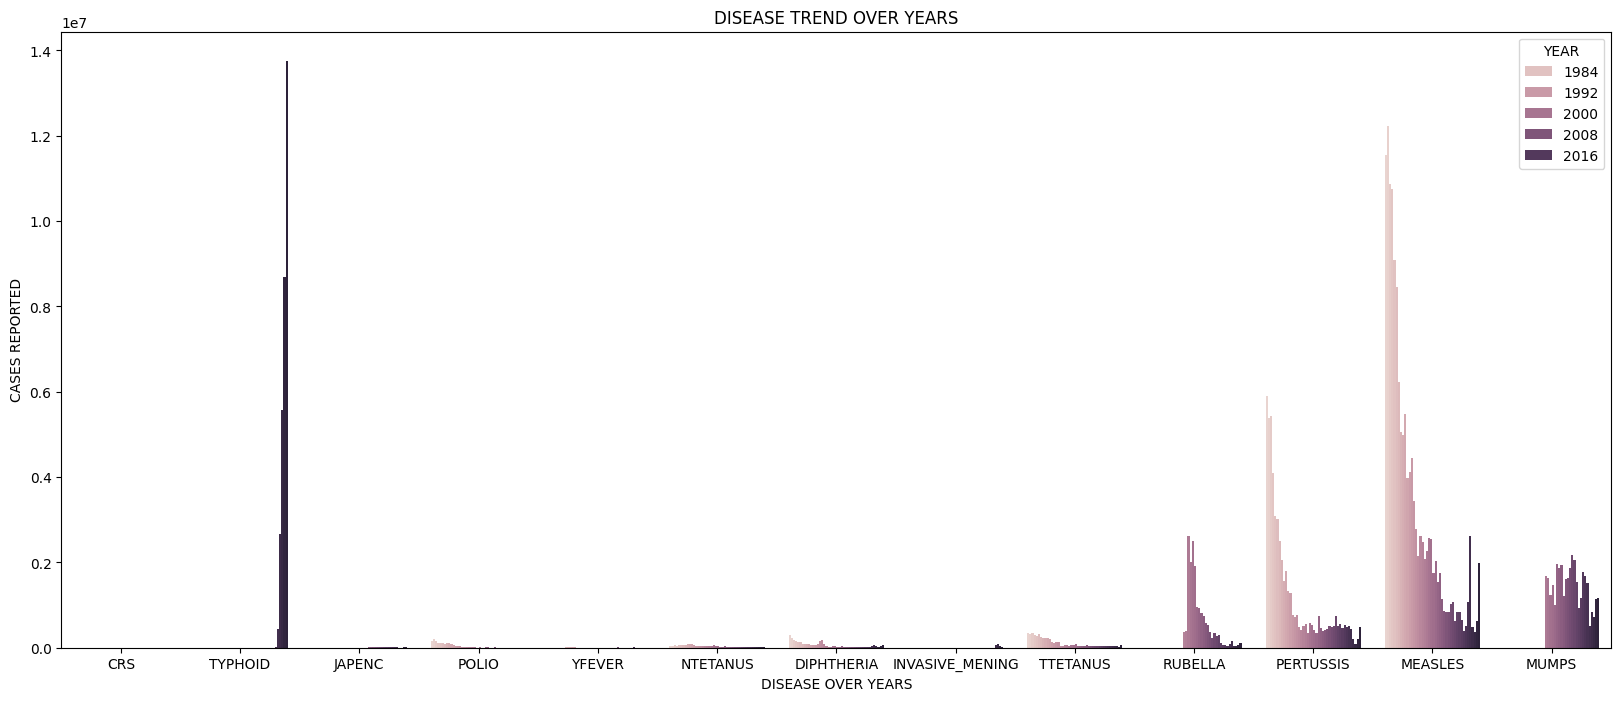

In [1484]:
#Year wise disease cases 
plt.figure(figsize=(20,8))
data = df4.groupby(['DISEASE', 'YEAR'])['CASES'].sum().sort_values().reset_index()
sns.barplot(data=data, x='DISEASE',y='CASES', hue='YEAR')
plt.xlabel('DISEASE OVER YEARS')
plt.ylabel('CASES REPORTED')
plt.title("DISEASE TREND OVER YEARS")
plt.show()

### DATA 4

In [21]:
df5= pd.read_excel("D:/Guvi/Projects/Vaccination/vaccine-introduction-data.xlsx")

In [19]:
df5

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes
3,AFG,Afghanistan,EMRO,2023.0,HepB birth dose,Yes
4,AFG,Afghanistan,EMRO,2023.0,Hib (Haemophilus influenzae type B) vaccine,Yes
...,...,...,...,...,...,...
138316,ZWE,Zimbabwe,AFRO,1943.0,Seasonal Influenza vaccine,No
138317,ZWE,Zimbabwe,AFRO,1942.0,Seasonal Influenza vaccine,No
138318,ZWE,Zimbabwe,AFRO,1941.0,Seasonal Influenza vaccine,No
138319,ZWE,Zimbabwe,AFRO,1940.0,Seasonal Influenza vaccine,No


In [22]:
df5.isnull().sum()

ISO_3_CODE     0
COUNTRYNAME    1
WHO_REGION     1
YEAR           1
DESCRIPTION    1
INTRO          1
dtype: int64

In [23]:
df5.dropna(inplace=True)
df5.isnull().sum()

ISO_3_CODE     0
COUNTRYNAME    0
WHO_REGION     0
YEAR           0
DESCRIPTION    0
INTRO          0
dtype: int64

In [24]:
df5['YEAR'] = df5['YEAR'].astype(int)

In [25]:
df5

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023,Hepatitis B vaccine,Yes
3,AFG,Afghanistan,EMRO,2023,HepB birth dose,Yes
4,AFG,Afghanistan,EMRO,2023,Hib (Haemophilus influenzae type B) vaccine,Yes
...,...,...,...,...,...,...
138315,ZWE,Zimbabwe,AFRO,1944,Seasonal Influenza vaccine,No
138316,ZWE,Zimbabwe,AFRO,1943,Seasonal Influenza vaccine,No
138317,ZWE,Zimbabwe,AFRO,1942,Seasonal Influenza vaccine,No
138318,ZWE,Zimbabwe,AFRO,1941,Seasonal Influenza vaccine,No


#### sql for data 4

In [51]:
table = """CREATE TABLE IF NOT EXISTS VACCINE_INTRO (
    ISO_3_CODE VARCHAR(100),
    COUNTRYNAME VARCHAR(100),
    WHO_REGION VARCHAR(100),
    DESCRIPTION VARCHAR(100),
    INTRO VARCHAR(15)
    )"""

In [52]:
connect.execute(table)
connection.commit()

In [53]:
insert = """INSERT INTO VACCINE_INTRO (ISO_3_CODE, COUNTRYNAME, WHO_REGION, DESCRIPTION, INTRO)
            VALUES(%s,%s,%s,%s,%s)"""

In [54]:
for index, row in df5.iterrows():
    connect.execute(insert, (
        row['ISO_3_CODE'],
        row['COUNTRYNAME'],
        row['WHO_REGION'],
        row['DESCRIPTION'],
        row['INTRO'],
    ))

In [55]:
connection.commit()

#### EDA

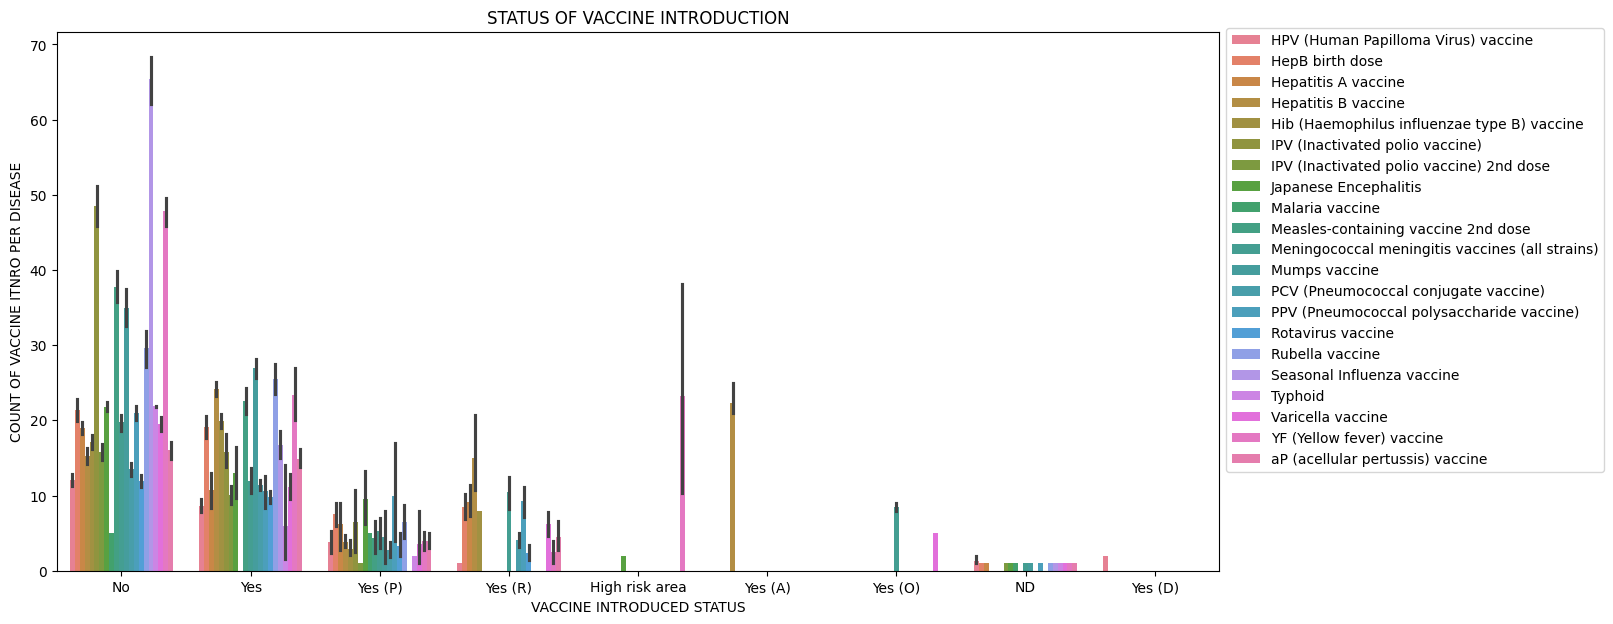

In [1571]:
plt.figure(figsize=(15,7))
data= df5.groupby(["ISO_3_CODE", "DESCRIPTION", 'INTRO']).size().reset_index(name="COUNT")
sns.barplot(data=data, x="INTRO", y= "COUNT", hue='DESCRIPTION')
plt.title("STATUS OF VACCINE INTRODUCTION")
plt.xlabel("VACCINE INTRODUCED STATUS")
plt.ylabel("COUNT OF VACCINE ITNRO PER DISEASE")
plt.legend(bbox_to_anchor=(1,1.02), loc="upper left")
plt.show()

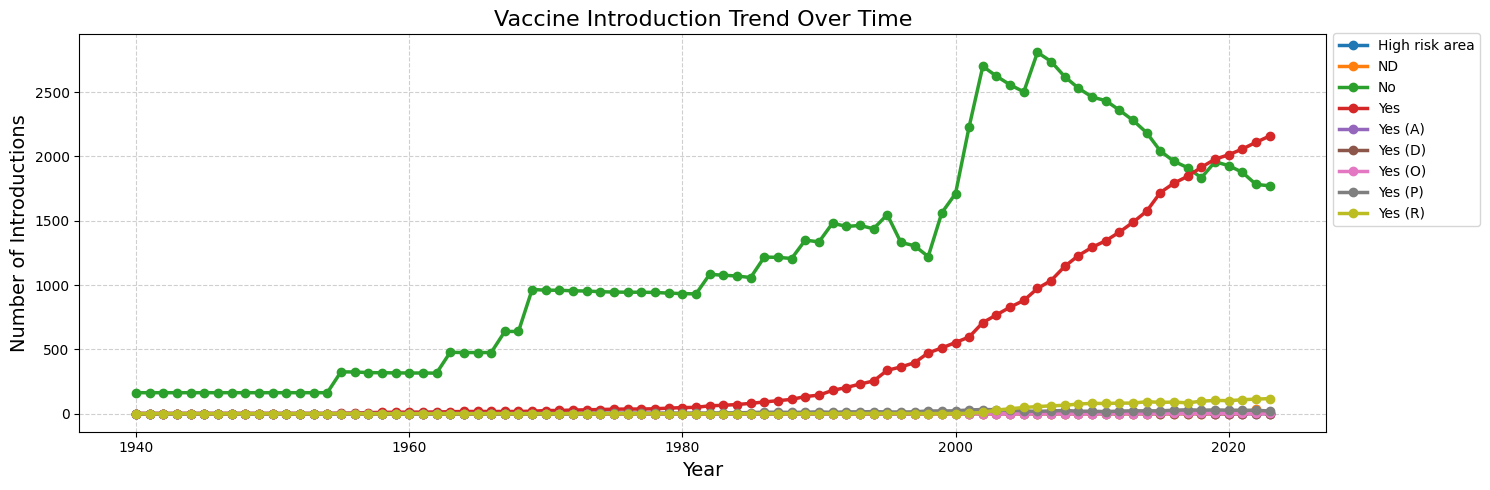

In [1573]:
plt.figure(figsize=(15,5))
data= df5.groupby(["YEAR", 'INTRO']).size().reset_index(name="COUNT")
pivot = data.pivot(index='YEAR', columns='INTRO', values='COUNT').fillna(0)

for column in pivot.columns:
    plt.plot(
        pivot.index,          # YEAR as x-axis
        pivot[column],       # COUNT as y-axis
        label=column,        # Legend label
        marker='o',
        linewidth=2.5,
    )

plt.title("Vaccine Introduction Trend Over Time", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Introductions", fontsize=14)
plt.legend(title='Introduction Status', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1,1.02), loc="upper left")
plt.tight_layout()
plt.show()

### DATA 5

In [1320]:
df6= pd.read_excel("D:/Guvi/Projects/Vaccination/vaccine-schedule-data.xlsx")

In [176]:
df6

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN
3,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4.0,B_2YL_W,General/routine,NATIONAL,M15,NaN
4,ABW,Aruba,AMRO,2023.0,DTAPIPV,DTaP-IPV (acellular) vaccine,5.0,B_CHILD_W,General/routine,NATIONAL,Y4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8048,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,3.0,NaN,General/routine,NATIONAL,M18,M6-M59
8049,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,4.0,NaN,General/routine,NATIONAL,M24,M6-M59
8050,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,5.0,NaN,General/routine,NATIONAL,M30,M6-M59
8051,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,6.0,NaN,General/routine,NATIONAL,M36,M6-M59


In [1321]:
df6.isnull().sum()

ISO_3_CODE                  0
COUNTRYNAME                 1
WHO_REGION                  1
YEAR                        1
VACCINECODE                 1
VACCINE_DESCRIPTION         1
SCHEDULEROUNDS              1
TARGETPOP                4258
TARGETPOP_DESCRIPTION       1
GEOAREA                    31
AGEADMINISTERED          1046
SOURCECOMMENT            2914
dtype: int64

In [74]:
target_age_map = df6.groupby("TARGETPOP")["AGEADMINISTERED"].unique()
print(target_age_map)

TARGETPOP
ADULTS        [>=65, 1st contact, +M1, +M6, +Y1, Y15-Y49, >Y...
BOTH          [Y9-15, Y11, +M6, Y9-Y13, +Y1, Y12-Y13, Y9, Y1...
B_2YL_F                                          [Y2, M24, M40]
B_2YL_W       [M15, M18, M15-M18, M16, M18-Y2, M18-M23, M18-...
B_ADO_F                                           [Y16, Y7, Y8]
B_ADO_W       [Y15, Y13, Y15-Y16, Y11, Y12-Y13, Y14-Y16, Y12...
B_CHILD_F                                            [Y3, Y3.6]
B_CHILD_W     [Y4, Y4-Y5, Y6, Y5, Y5-Y6, Y6-Y8, Y5-Y7, Y4-Y6...
CATCHUP_A     [<Y25, Y71-Y79, <Y21, >=65, +Y1, 1st contact, ...
CATCHUP_C     [<Y25, Y7-Y15, <Y21, >=65, 1st contact, +M1, +...
FEMALE        [Y11, +M6, Y13, Y12, Y14, Y9, Y10-Y13, Y10, Y9...
HW            [1st contact, +M5, +M1, +M6, >=65, +Y5, +W6, +...
PW            [1st contact, +M1, +M6, +Y1, >=65, +W4, +M6-Y1...
RISKGROUPS    [1st contact, +M1, +M5, >=65, >=Y1, >Y4, +M6, ...
TRAVELLERS    [1st contact, +M6, >=65, +M1, 1st Contact, >=Y...
Name: AGEADMINISTERED, dtype: 

In [1322]:
#dropping NA in a scpecific coloumn

df6.dropna(subset=["AGEADMINISTERED"], inplace=True)
df6

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN
3,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4.0,B_2YL_W,General/routine,NATIONAL,M15,NaN
4,ABW,Aruba,AMRO,2023.0,DTAPIPV,DTaP-IPV (acellular) vaccine,5.0,B_CHILD_W,General/routine,NATIONAL,Y4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8047,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,2.0,NaN,General/routine,NATIONAL,M12,M6-M59
8048,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,3.0,NaN,General/routine,NATIONAL,M18,M6-M59
8049,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,4.0,NaN,General/routine,NATIONAL,M24,M6-M59
8050,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,5.0,NaN,General/routine,NATIONAL,M30,M6-M59


In [1323]:
#dropping of a columns as its not neccessary for the viz 
df6.drop(["SOURCECOMMENT"], axis=1, inplace=True)
df6

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6
3,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4.0,B_2YL_W,General/routine,NATIONAL,M15
4,ABW,Aruba,AMRO,2023.0,DTAPIPV,DTaP-IPV (acellular) vaccine,5.0,B_CHILD_W,General/routine,NATIONAL,Y4
...,...,...,...,...,...,...,...,...,...,...,...
8047,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,2.0,NaN,General/routine,NATIONAL,M12
8048,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,3.0,NaN,General/routine,NATIONAL,M18
8049,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,4.0,NaN,General/routine,NATIONAL,M24
8050,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,5.0,NaN,General/routine,NATIONAL,M30


In [116]:
area = df6.groupby("GEOAREA")["ISO_3_CODE"].unique()
print(area)



GEOAREA
NATIONAL       [ABW, AFG, AGO, AIA, ALB, AND, ARE, ARG, ARM, ...
SUBNATIONAL    [ARG, AUS, BEL, BGR, BHS, CAN, CHE, CHL, CHN, ...
Name: ISO_3_CODE, dtype: object


In [1324]:
#FILLING NA values IN GEAOAREA

df6.loc[(df6["WHO_REGION"] == "AFRO") & (df6["GEOAREA"].isna()), "GEOAREA"] = "NATIONAL"
df6.loc[(df6["WHO_REGION"] == "AMRO") & (df6["GEOAREA"].isna()), "GEOAREA"] = "NATIONAL"
df6.loc[(df6["WHO_REGION"] == "EURO") & (df6["GEOAREA"].isna()), "GEOAREA"] = "NATIONAL"
df6.loc[(df6["WHO_REGION"] == "SEARO") & (df6["GEOAREA"].isna()), "GEOAREA"] = "NATIONAL"
df6.loc[(df6["WHO_REGION"] == "WPRORO") & (df6["GEOAREA"].isna()), "GEOAREA"] = "NATIONAL"

In [1325]:
#dropping the remanining null the geoarea
df6.dropna(subset=["GEOAREA"], inplace=True)

In [1337]:
df6.isnull().sum()

ISO_3_CODE               0
COUNTRYNAME              0
WHO_REGION               0
YEAR                     0
VACCINECODE              0
VACCINE_DESCRIPTION      0
SCHEDULEROUNDS           0
TARGETPOP                0
TARGETPOP_DESCRIPTION    0
GEOAREA                  0
AGEADMINISTERED          0
dtype: int64

In [1327]:
#filling target group 

df6.loc[(df6["WHO_REGION"] == "AFRO") & (df6["AGEADMINISTERED"] == "+M1") & (df6["TARGETPOP"].isna()), "TARGETPOP"] = "ADULTS"
df6.loc[(df6["WHO_REGION"] == "AFRO") & (df6["AGEADMINISTERED"] == "+M12") & (df6["TARGETPOP"].isna()), "TARGETPOP"] = "ADULTS"
df6.loc[(df6["WHO_REGION"] == "AFRO") & (df6["AGEADMINISTERED"] == "+M6") & (df6["TARGETPOP"].isna()), "TARGETPOP"] = "ADULTS"
df6.loc[(df6["WHO_REGION"] == "AFRO") & (df6["COUNTRYNAME"].isin(["Ethiopia" , "Botswana"])) & (df6["AGEADMINISTERED"] == "+W4") & (df6["TARGETPOP"].isna()), "TARGETPOP"] = "ADULTS"
df6.loc[(df6["WHO_REGION"] == "AFRO") & (df6["AGEADMINISTERED"] == "+W4") & (df6["TARGETPOP"].isna()), "TARGETPOP"] = "ADULTS"
df6.loc[(df6["WHO_REGION"] == "AFRO") & (df6["AGEADMINISTERED"] == "+Y1") & (df6["TARGETPOP"].isna()), "TARGETPOP"] = "ADULTS"
df6.loc[(df6["WHO_REGION"] == "AFRO") & (df6["AGEADMINISTERED"] == "+Y2") & (df6["TARGETPOP"].isna()), "TARGETPOP"] = "ADULTS"
df6.loc[(df6["WHO_REGION"] == "AFRO") & (df6["AGEADMINISTERED"] == "1st contact") & (df6["TARGETPOP"].isna()), "TARGETPOP"] = "ADULTS"

In [1328]:

df6.loc[(df6["AGEADMINISTERED"] == "B") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y10-Y11") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["VACCINECODE"] == "MMR") & (df6["AGEADMINISTERED"]=="Y10-Y11") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "FEMALE"
df6.loc[(df6["AGEADMINISTERED"]=="Y10-Y13") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y10-Y19") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["COUNTRYNAME"] == "Saudi Arabia") & (df6["AGEADMINISTERED"]=="Y11") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "RISKGROUPS"
df6.loc[(df6["AGEADMINISTERED"]=="Y11") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"

In [1329]:
df6.loc[(df6["AGEADMINISTERED"]=="Y11-Y12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y11-Y15") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["COUNTRYNAME"]== "Saudi Arabia")& (df6["AGEADMINISTERED"]=="Y12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "RISKGROUPS"
df6.loc[(df6["AGEADMINISTERED"]=="Y12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y12-Y13") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y12-Y18") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"


In [1330]:
df6.loc[(df6["AGEADMINISTERED"]=="Y13") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y14") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y14.5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y14-Y15") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y14-Y16") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y15") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y15-Y16") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y15-Y39") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="Y15-Y49") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="Y16") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y16-Y18") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y16-Y49") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="Y17") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="Y17-Y18") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"

In [1331]:
df6.loc[(df6["AGEADMINISTERED"]=="Y18") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="Y18-Y25") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "FEMALE"
df6.loc[(df6["AGEADMINISTERED"]=="Y1-Y17") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "RISKGROUPS"
df6.loc[(df6["AGEADMINISTERED"]=="Y1-Y14") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "RISKGROUPS"
df6.loc[(df6["AGEADMINISTERED"]=="Y2") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y2.5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y2-Y17") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "RISKGROUPS"
df6.loc[(df6["AGEADMINISTERED"]=="Y2-Y14") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y2-Y18") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y2-Y3") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y2-Y5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y2-Y6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y3") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y3.5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y3") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y3-Y17") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y4") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y3-Y5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y4.5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y3-Y4") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="Y4.5-Y5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y4-Y5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y4-Y6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y4-Y18") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y4-Y10") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y5-Y6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y5-Y10") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y5-Y18") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y5-Y16") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y5-Y7") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y6-Y7") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y6-Y8") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y7") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y7-Y12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y7-Y49") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="Y9-Y14") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y9-Y17") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="Y9") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"


In [1332]:
df6.loc[(df6["AGEADMINISTERED"]=="+D7-D30") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "RISKGROUPS"
df6.loc[(df6["AGEADMINISTERED"]=="+M1") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+M12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+M1-M3") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+M13") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+M5-M12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]=="+M6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+M6-M18") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+M6-M12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+W4") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+W4-W6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+Y1") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="+Y2") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["WHO_REGION"]=="EURO")&(df6["TARGETPOP_DESCRIPTION"]=="General/routine")&(df6["AGEADMINISTERED"]=="+Y3") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "TRAVELLERS"
df6.loc[(df6["AGEADMINISTERED"]=="+Y3") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]=="<=Y9") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "CATCHUP_C"
df6.loc[(df6["AGEADMINISTERED"]=="<W33") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "CATCHUP_C"
df6.loc[(df6["AGEADMINISTERED"]=="<Y1") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "CATCHUP_C"

In [1333]:
df6.loc[(df6["AGEADMINISTERED"]==">=M13") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_W"
df6.loc[(df6["AGEADMINISTERED"]==">=M6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_W"
df6.loc[(df6["AGEADMINISTERED"]==">=M9") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_W"
df6.loc[(df6["AGEADMINISTERED"]==">=Y1") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_W"
df6.loc[(df6["AGEADMINISTERED"]==">=Y11") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]==">=Y16") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]==">=Y10") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]==">=Y3") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]==">=Y4") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]==">=Y6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_F"
df6.loc[(df6["AGEADMINISTERED"]==">=Y7") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]==">M12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "TRAVELLERS"
df6.loc[(df6["AGEADMINISTERED"]==">=M12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "TRAVELLERS"
df6.loc[(df6["AGEADMINISTERED"]==">M6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_W"
df6.loc[(df6["AGEADMINISTERED"]==">Y10") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]==">Y14") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]==">Y18") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]==">Y15") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"
df6.loc[(df6["AGEADMINISTERED"]==">Y3") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]==">Y7") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]==">Y6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]==">Y5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]==">Y9") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="1st contact") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "ADULTS"

In [1334]:
df6.loc[(df6["AGEADMINISTERED"]=="M12-M35") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M6-Y9") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="M6-M35") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M6-Y5") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="M6-Y6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="M26-M32") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M6-M59") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M33-M39") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M40-M46") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M1-Y12") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="M6-Y4") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M6-Y7") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="M12-Y59") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M24-Y6") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_F"
df6.loc[(df6["AGEADMINISTERED"]=="M42") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="M40") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M23-M59") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="M24-M47") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="M42") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"
df6.loc[(df6["AGEADMINISTERED"]=="M6-M36") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M36-Y17") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_ADO_W"
df6.loc[(df6["AGEADMINISTERED"]=="M37") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_2YL_F"
df6.loc[(df6["AGEADMINISTERED"]=="M48") & (df6["TARGETPOP"].isna()), "TARGETPOP" ] = "B_CHILD_W"

In [1335]:
#FILLING THE REMAINING B TO M26 WITH B_2YL_W
df6["TARGETPOP"] = df6["TARGETPOP"].fillna("B_2YL_W")

In [1336]:
df6

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,B_2YL_W,General/routine,NATIONAL,M2
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,B_2YL_W,General/routine,NATIONAL,M4
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,B_2YL_W,General/routine,NATIONAL,M6
3,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4.0,B_2YL_W,General/routine,NATIONAL,M15
4,ABW,Aruba,AMRO,2023.0,DTAPIPV,DTaP-IPV (acellular) vaccine,5.0,B_CHILD_W,General/routine,NATIONAL,Y4
...,...,...,...,...,...,...,...,...,...,...,...
8047,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,2.0,B_2YL_W,General/routine,NATIONAL,M12
8048,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,3.0,B_2YL_W,General/routine,NATIONAL,M18
8049,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,4.0,B_2YL_W,General/routine,NATIONAL,M24
8050,ZWE,Zimbabwe,AFRO,2023.0,VITAMINA,Vitamin A supplements,5.0,B_2YL_W,General/routine,NATIONAL,M30


In [207]:
df6['YEAR'] = df6['YEAR'].astype(int)
df6['SCHEDULEROUNDS'] = df6['SCHEDULEROUNDS'].astype(int)


#### sql for data 5

In [220]:
table = """CREATE TABLE IF NOT EXISTS VACCINE_SCHEDULE (
    ISO_3_CODE VARCHAR(100),
    COUNTRYNAME VARCHAR(100),
    WHO_REGION VARCHAR(100),
    YEAR INT,
    VACCINECODE VARCHAR(100),
    VACCINE_DESCRIPTION VARCHAR(100),
    SCHEDULEROUNDS INT,
    TARGETPOP VARCHAR(100),
    TARGETPOP_DESCRIPTION VARCHAR(100), 
    GEOAREA VARCHAR(100),
    AGEADMINISTERED VARCHAR(100)
    )
    """

In [221]:
connect.execute(table)
connection.commit()

In [226]:
insert = """INSERT INTO VACCINE_SCHEDULE (ISO_3_CODE, COUNTRYNAME, WHO_REGION, YEAR, VACCINECODE, VACCINE_DESCRIPTION, SCHEDULEROUNDS, TARGETPOP, TARGETPOP_DESCRIPTION, GEOAREA, AGEADMINISTERED )
            VALUES(%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)"""

In [227]:
for index, row in df6.iterrows():
    connect.execute(insert, (
        row['ISO_3_CODE'],
        row['COUNTRYNAME'],
        row['WHO_REGION'],
        row['YEAR'],
        row['VACCINECODE'],
        row['VACCINE_DESCRIPTION'],
        row['SCHEDULEROUNDS'],
        row['TARGETPOP'],
        row['TARGETPOP_DESCRIPTION'],
        row['GEOAREA'],
        row['AGEADMINISTERED']
    ))

In [228]:
connection.commit()

#### EDA

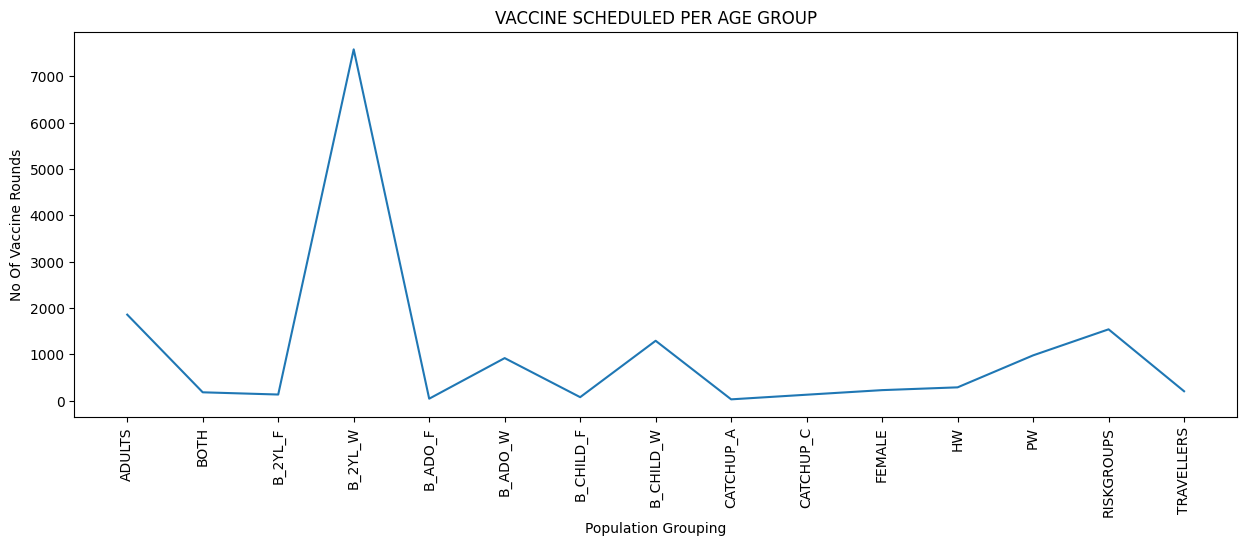

In [1568]:
data = df6.groupby('TARGETPOP').sum().reset_index()
plt.figure(figsize=(15,5))
sns.lineplot(data=data, x='TARGETPOP', y= 'SCHEDULEROUNDS')
plt.xlabel("Population Grouping")
plt.ylabel("No Of Vaccine Rounds")
plt.xticks(rotation = 90)
plt.title("VACCINE SCHEDULED PER AGE GROUP")
plt.show()

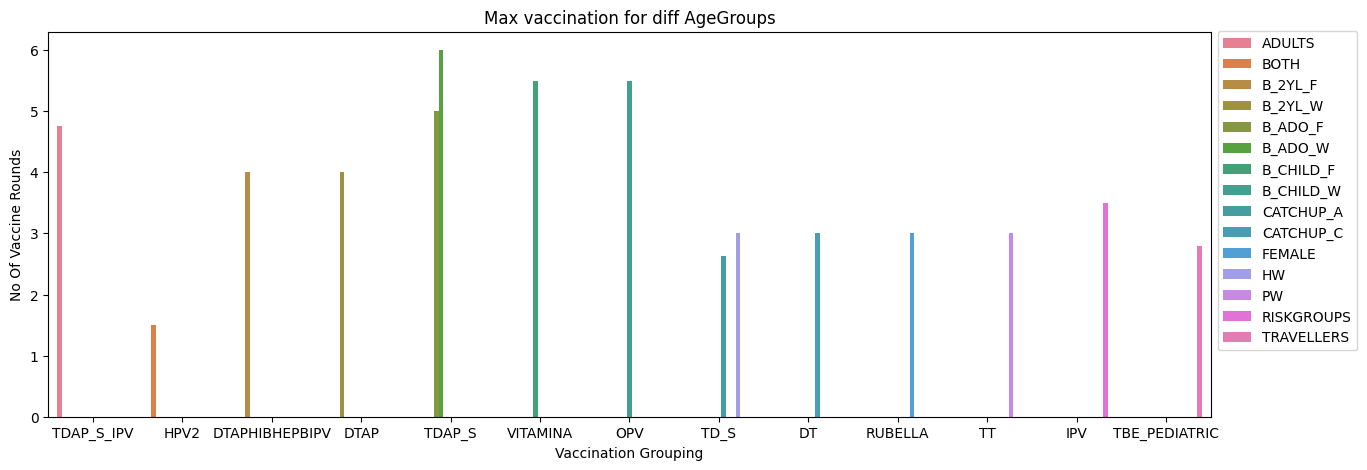

         VACCINECODE                                VACCINE_DESCRIPTION
0         DTAPHIBIPV                   DTaP-Hib-IPV (acellular) vaccine
4            DTAPIPV                       DTaP-IPV (acellular) vaccine
9         HEPA_ADULT                          Adult Hepatitis A vaccine
11    HEPA_PEDIATRIC                      Pediatric Hepatitis A vaccine
13        HEPB_ADULT                          Adult Hepatitis B vaccine
...              ...                                                ...
6238         RUBELLA                                    Rubella vaccine
6917           DTIPV  DT-IPV (Diphtheria and tetanus toxoid and IPV)...
7256             HPV                HPV (Human Papilloma Virus) vaccine
7552          DENGUE                                     Dengue vaccine
7575           EBOLA                                      Ebola vaccine

[82 rows x 2 columns]


In [1569]:
#top vaccine on each age group 
data = df6.groupby(['VACCINECODE','YEAR', 'TARGETPOP'])["SCHEDULEROUNDS"].mean().reset_index()
sort= data.loc[data.groupby('TARGETPOP')["SCHEDULEROUNDS"].idxmax()]
plt.figure(figsize=(15,5))
sns.barplot(data=sort, x='VACCINECODE', y= 'SCHEDULEROUNDS',hue="TARGETPOP")
plt.xlabel("Vaccination Grouping")
plt.ylabel("No Of Vaccine Rounds")
plt.title("Max vaccination for diff AgeGroups")
plt.legend(bbox_to_anchor=(1,1.02), loc="upper left")
plt.show()

unique_vaccines = df6[['VACCINECODE', 'VACCINE_DESCRIPTION']].drop_duplicates()
print(unique_vaccines)


